In [1]:
import sys
from pathlib import Path

# Adjust if needed
PROJECT_ROOT = Path(".").resolve()
sys.path.append(str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DatasetClassification_gradient_accum import (
    ConvNeXtTinyClassifier,
    DatasetClassificationDataset,
    eval_transform,
    load_splits,
)

In [2]:
def load_trained_model(checkpoint_path, num_classes, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model = ConvNeXtTinyClassifier(num_classes=num_classes)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()

    return model, ckpt

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT = r"outputs_dataset_classification\CocoReLaionSDBase\model_seed_0.pt"
SPLITS_JSON = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\7_DatasetPreparation\UniversalSplits\DatasetClassificationCoco\coco_splits_face_combined_stratified_depth.json"

model, ckpt = load_trained_model(
    CHECKPOINT,
    num_classes=3,
    device=DEVICE
)

In [ ]:
train_samples, val_samples, test_samples = load_splits(SPLITS_JSON)

test_dataset = DatasetClassificationDataset(
    test_samples,
    eval_transform()
)

In [7]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import torch

@torch.no_grad()
def run_inference(model, dataset, batch_size=128, num_workers=8):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    preds, targets, probs = [], [], []

    device = next(model.parameters()).device
    total_images = len(dataset)

    pbar = tqdm(
        total=total_images,
        desc="Running inference",
        unit="img"
    )

    for images, y in loader:
        images = images.to(device)
        y = y.to(device)

        logits = model(images)
        p = F.softmax(logits, dim=1)
        pred = p.argmax(dim=1)

        preds.append(pred.cpu().numpy())
        targets.append(y.cpu().numpy())
        probs.append(p.cpu().numpy())

        # update progress by number of images processed
        pbar.update(images.size(0))

    pbar.close()

    return (
        np.concatenate(preds),
        np.concatenate(targets),
        np.concatenate(probs),
    )


In [13]:
y_pred, y_true, y_probs = run_inference(model, test_dataset)

Running inference: 100%|██████████| 98573/98573 [03:35<00:00, 456.85img/s]


In [9]:
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["Re-Laion 5B", "StableDiffusion", "Coco"]

def plot_confusion_matrix(y_true, y_pred, class_names, normalize=True):
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Normalized)")
    plt.tight_layout()
    plt.show()

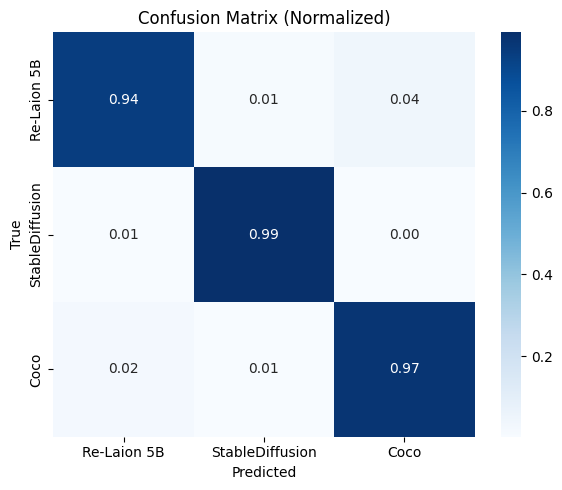

In [15]:
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

In [13]:
def per_class_accuracy(y_true, y_pred, class_names):
    for i, name in enumerate(class_names):
        idx = (y_true == i)
        acc = (y_pred[idx] == i).mean()
        print(f"{name:10s}: {acc*100:.2f}%")

In [17]:
per_class_accuracy(y_true, y_pred, CLASS_NAMES)

Re-Laion 5B: 94.12%
StableDiffusion: 99.14%
Coco      : 96.87%


In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_ovr_roc(y_true, y_probs, class_names):
    y_bin = label_binarize(y_true, classes=range(len(class_names)))

    plt.figure(figsize=(7, 6))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


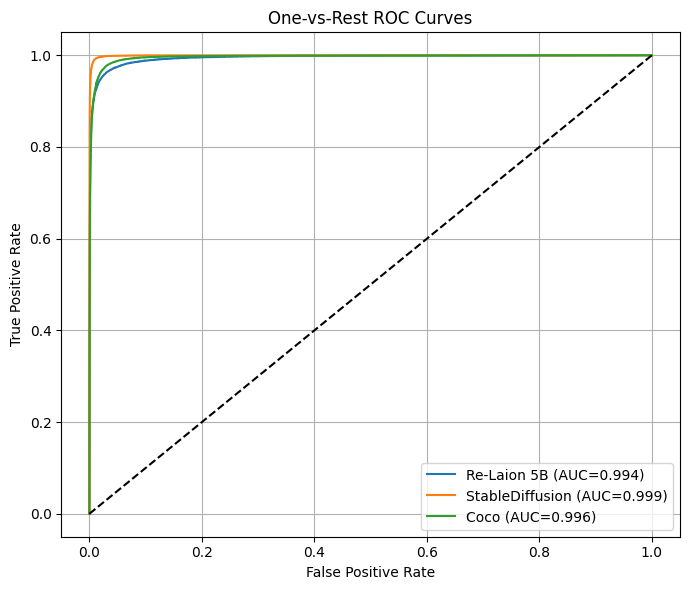

In [ ]:
plot_ovr_roc(y_true, y_probs, CLASS_NAMES)

In [17]:
def collect_confusion_examples(
    samples,
    y_true,
    y_pred,
    from_class,
    to_class,
    max_examples=12
):
    idx = np.where((y_true == from_class) & (y_pred == to_class))[0]
    return [samples[i][0] for i in idx[:max_examples]]


In [21]:
# CC → DataComp confusions
confused_paths = collect_confusion_examples(
    test_samples,
    y_true,
    y_pred,
    from_class=1,
    to_class=2
)

confused_paths[:5]


['F:\\ImageRetrieval\\SpuriousFeatureImages\\StableDiffusionImages\\Depth\\\\Payroll Specialist\\Payroll Specialist_001128_1859a3_Depth.png',
 'F:\\ImageRetrieval\\SpuriousFeatureImages\\StableDiffusionImages\\Depth\\\\Florist\\Florist_000801_fc36db_Depth.png',
 'F:\\ImageRetrieval\\SpuriousFeatureImages\\StableDiffusionImages\\Depth\\\\Makeup Artist\\Makeup Artist_000445_9b5ffe_Depth.png',
 'F:\\ImageRetrieval\\SpuriousFeatureImages\\StableDiffusionImages\\Depth\\\\Florist\\Florist_000652_910bcd_Depth.png',
 'F:\\ImageRetrieval\\SpuriousFeatureImages\\StableDiffusionImages\\Depth\\\\Tennis Player\\Tennis Player_001321_6eb028_Depth.png']

In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    # def generate(self, input_tensor, class_idx):
    #     self.model.zero_grad()

    #     logits = self.model(input_tensor)
    #     score = logits[:, class_idx].sum()
    #     score.backward()

    #     # Grad-CAM computation
    #     weights = self.gradients.mean(dim=(2, 3), keepdim=True)
    #     cam = (weights * self.activations).sum(dim=1)

    #     cam = torch.relu(cam)
    #     cam = cam - cam.min()
    #     cam = cam / (cam.max() + 1e-8)

    #     return cam

    import torch.nn.functional as F

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        logits = self.model(input_tensor)
        score = logits[:, class_idx].sum()
        score.backward()

        # Grad-CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        # 🔴 IMPORTANT: upsample to input resolution
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],  # (H, W) of input
            mode="bilinear",
            align_corners=False
        )

        # Normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam


In [21]:
# def run_inference_with_gradcam(
#     model,
#     dataset,
#     batch_size=128,
#     num_workers=8,
#     compute_gradcam=False,
#     max_cams=50,   # limit for speed
# ):
#     loader = DataLoader(
#         dataset,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=num_workers,
#         pin_memory=True
#     )

#     device = next(model.parameters()).device
#     preds, targets, probs, cams = [], [], [], []

#     gradcam = None
#     if compute_gradcam:
#         gradcam = GradCAM(
#             model,
#             target_layer=model.backbone.features[-1]
#         )

#     total_images = len(dataset)
#     pbar = tqdm(total=total_images, desc="Inference", unit="img")

#     for images, y in loader:
#         images = images.to(device)
#         y = y.to(device)

#         # Normal inference (no grad)
#         with torch.no_grad():
#             logits = model(images)
#             p = F.softmax(logits, dim=1)
#             pred = p.argmax(dim=1)

#         preds.append(pred.cpu().numpy())
#         targets.append(y.cpu().numpy())
#         probs.append(p.cpu().numpy())

#         # Grad-CAM (selective, expensive)
#         if compute_gradcam and len(cams) < max_cams:
#             for i in range(images.size(0)):
#                 if len(cams) >= max_cams:
#                     break

#                 img = images[i:i+1]
#                 cls = pred[i].item()

#                 cam = gradcam.generate(img, cls)
#                 cams.append({
#                     "cam": cam.cpu(),
#                     "image": img.cpu(),
#                     "pred": cls,
#                     "true": y[i].item()
#                 })

#         pbar.update(images.size(0))

#     pbar.close()

#     return (
#         np.concatenate(preds),
#         np.concatenate(targets),
#         np.concatenate(probs),
#         cams,  # list of CAM tensors
#     )

def run_inference_with_gradcam(
    model,
    dataset,
    batch_size=128,
    num_workers=8,
    compute_gradcam=False,
    max_cams=50,
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    device = next(model.parameters()).device
    preds, targets, probs, cams = [], [], [], []

    gradcam = None
    if compute_gradcam:
        gradcam = GradCAM(
            model,
            target_layer=model.backbone.features[-1]
        )

    processed = 0
    total_to_process = max_cams if compute_gradcam else len(dataset)

    pbar = tqdm(total=total_to_process, desc="Inference", unit="img")

    for images, y in loader:

        # If we've already processed enough, stop
        if processed >= total_to_process:
            break

        # Trim batch if it exceeds remaining quota
        remaining = total_to_process - processed
        if images.size(0) > remaining:
            images = images[:remaining]
            y = y[:remaining]

        images = images.to(device)
        y = y.to(device)

        # Forward pass
        with torch.no_grad():
            logits = model(images)
            p = F.softmax(logits, dim=1)
            pred = p.argmax(dim=1)

        preds.append(pred.cpu().numpy())
        targets.append(y.cpu().numpy())
        probs.append(p.cpu().numpy())

        # Grad-CAM (only for requested images)
        if compute_gradcam:
            for i in range(images.size(0)):
                img = images[i:i+1]
                cls = pred[i].item()

                cam = gradcam.generate(img, cls)
                cams.append({
                    "cam": cam.cpu(),
                    "image": img.cpu(),
                    "pred": cls,
                    "true": y[i].item()
                })

        processed += images.size(0)
        pbar.update(images.size(0))

    pbar.close()

    return (
        np.concatenate(preds) if preds else np.array([]),
        np.concatenate(targets) if targets else np.array([]),
        np.concatenate(probs) if probs else np.array([]),
        cams,
    )


In [20]:
import numpy as np
import matplotlib.pyplot as plt

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def _to_numpy_image(img_tensor, denormalize=True):
    """
    Convert torch tensor image to numpy array suitable for visualization.

    Accepts:
      - [1, C, H, W]
      - [C, H, W]
      - [H, W]

    Returns:
      - RGB image: [H, W, 3]
      - Grayscale image: [H, W]
    """
    if hasattr(img_tensor, "detach"):
        img = img_tensor.detach().cpu().numpy()
    else:
        img = img_tensor

    # Remove batch dim
    if img.ndim == 4:
        img = img[0]

    # CHW → HWC
    if img.ndim == 3:
        C, H, W = img.shape

        # RGB
        if C == 3:
            if denormalize:
                img = img * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
            img = np.transpose(img, (1, 2, 0))
            img = np.clip(img, 0, 1)
            return img

        # Single-channel (depth, edge, mask)
        elif C == 1:
            img = img[0]
            return img

    # Already HW
    if img.ndim == 2:
        return img

    raise ValueError(f"Unsupported image shape for visualization: {img.shape}")

def show_cam(entry, class_names=None, title=None, alpha=0.5):
    """
    Universal Grad-CAM visualization.

    entry must contain:
      - entry["image"]: input tensor
      - entry["cam"]: Grad-CAM tensor
      - entry["true"] (optional)
      - entry["pred"] (optional)
    """

    img = _to_numpy_image(entry["image"])
    cam = entry["cam"].squeeze().cpu().numpy()

    # Normalize CAM
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    plt.figure(figsize=(8, 4))

    # -------- Image --------
    plt.subplot(1, 2, 1)
    if title:
        plt.title(title)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")

    # -------- CAM overlay --------
    plt.subplot(1, 2, 2)

    subtitle = "Grad-CAM"
    if class_names and "true" in entry and "pred" in entry:
        subtitle += (
            f"\nTrue: {class_names[entry['true']]} | "
            f"Pred: {class_names[entry['pred']]}"
        )

    plt.title(subtitle)

    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)

    plt.imshow(cam, cmap="jet", alpha=alpha)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


In [38]:
y_pred, y_true, y_probs, cams = run_inference_with_gradcam(
    model=model,
    dataset=test_dataset,
    batch_size=128,
    num_workers=8,
    compute_gradcam=True,
    max_cams=24,   # start small (12–24 is ideal)
)

Inference: 100%|██████████| 98573/98573 [03:33<00:00, 461.52img/s]


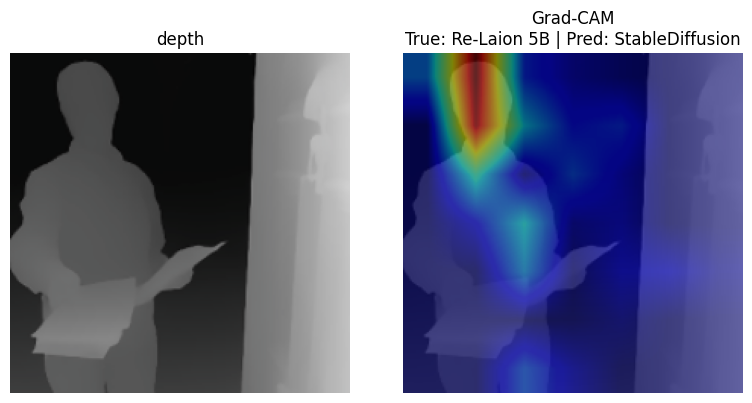

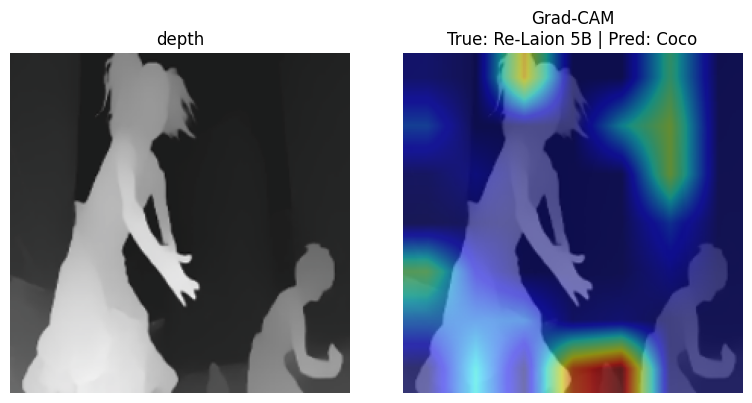

In [39]:
CLASS_NAMES = ["Re-Laion 5B", "StableDiffusion", "Coco"]

misclassified = [
    c for c in cams if c["true"] != c["pred"]
]

for entry in misclassified[:6]:
    show_cam(entry, CLASS_NAMES, "depth")


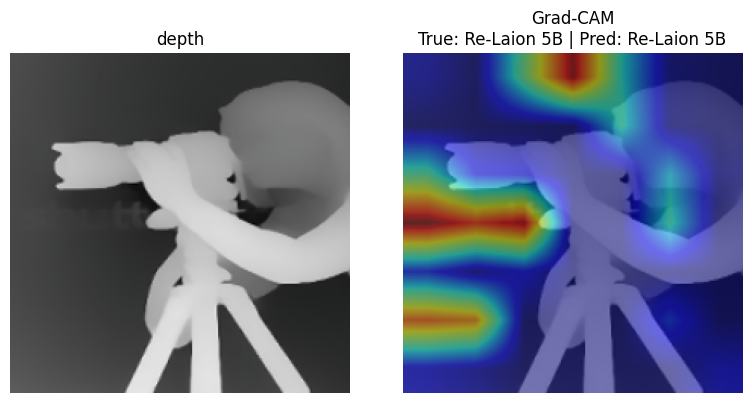

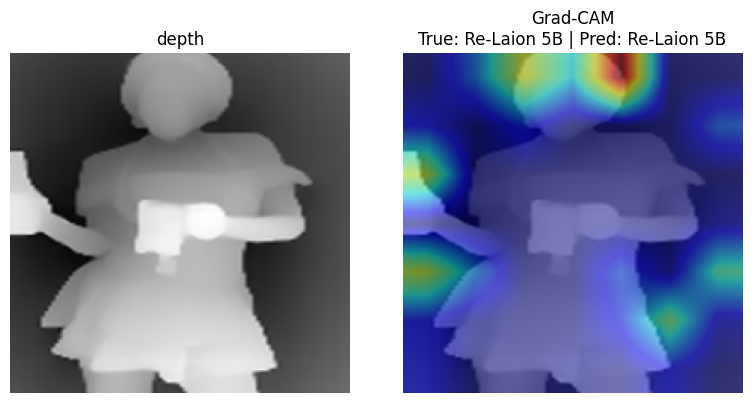

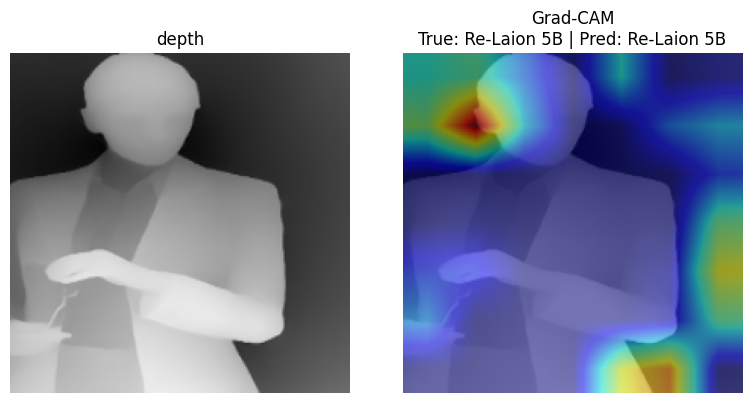

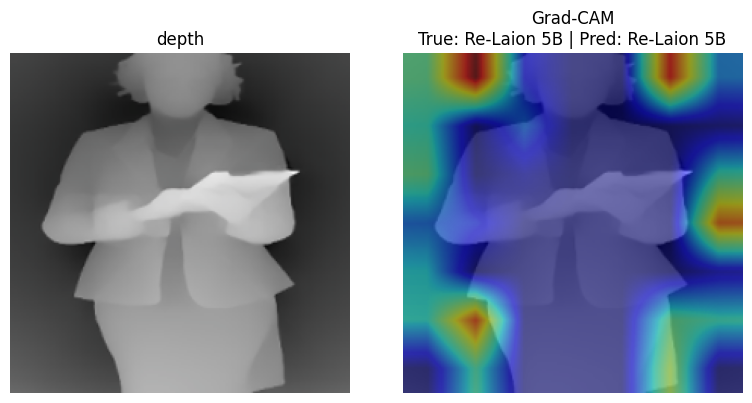

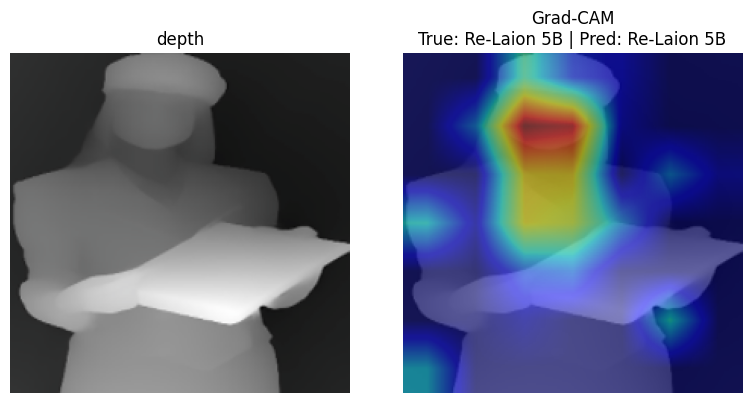

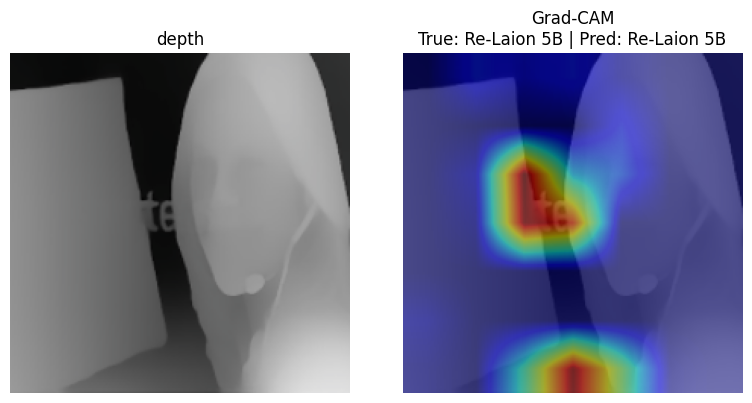

In [40]:
CLASS_NAMES = ["Re-Laion 5B", "StableDiffusion", "Coco"]

correct = [
    c for c in cams if c["true"] == c["pred"]
]

for entry in correct[:6]:
    show_cam(entry, CLASS_NAMES, "depth")


In [4]:
from PIL import Image
import torch
import torch.nn.functional as F
import numpy as np

def predict_image(
    model,
    image_path,
    device,
    transform,
    class_names=None
):
    model.eval()

    # 1. Load image
    img = Image.open(image_path).convert("RGB")

    # 2. Apply eval transform
    x = transform(img).unsqueeze(0).to(device)  # add batch dim

    # 3. Forward pass
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).item()

    probs_np = probs.cpu().numpy()[0]

    if class_names is not None:
        pred_label = class_names[pred]
    else:
        pred_label = pred

    return {
        "pred_index": pred,
        "pred_label": pred_label,
        "probabilities": probs_np
    }


In [14]:
CLASS_NAMES = ["Re-Laion 5B", "StableDiffusion", "Coco"]  # adjust to your setup

result = predict_image(
    model,
    image_path=r"G:\Thesis\0000_images\6.jpg",
    device=DEVICE,
    transform=eval_transform(),
    class_names=CLASS_NAMES
)

print(result)
print("Prediction:", result["pred_label"])
print("Probabilities:", result["probabilities"])

{'pred_index': 2, 'pred_label': 'Coco', 'probabilities': array([0.11569348, 0.05228647, 0.83202004], dtype=float32)}
Prediction: Coco
Probabilities: [0.11569348 0.05228647 0.83202004]


In [15]:
import os
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm


def run_directory_inference(
    model,
    image_dir,
    device,
    transform,
    class_names,
    max_images=1000
):
    model.eval()

    image_dir = Path(image_dir)

    image_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff"}

    all_preds = []
    all_probs = []

    processed = 0

    with torch.no_grad():
        for img_path in tqdm(image_dir.iterdir(), desc="Processing images"):
            if processed >= max_images:
                break

            if img_path.suffix.lower() not in image_extensions:
                continue

            try:
                img = Image.open(img_path).convert("RGB")
                x = transform(img).unsqueeze(0).to(device)

                logits = model(x)
                probs = F.softmax(logits, dim=1)
                pred = probs.argmax(dim=1).item()

                all_preds.append(pred)
                all_probs.append(probs.cpu().numpy()[0])

                processed += 1

            except Exception as e:
                print(f"Skipping {img_path.name}: {e}")
                continue

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # ==========================
    # Breakdown
    # ==========================
    counts = Counter(all_preds)
    total = len(all_preds)

    print("\n========== CLASS BREAKDOWN ==========")
    for idx, name in enumerate(class_names):
        count = counts.get(idx, 0)
        pct = (count / total) * 100 if total > 0 else 0
        print(f"{name:20s}: {count:5d} ({pct:6.2f}%)")

    print("\n========== MEAN CONFIDENCE PER CLASS ==========")
    for idx, name in enumerate(class_names):
        if counts.get(idx, 0) > 0:
            mean_conf = all_probs[all_preds == idx, idx].mean()
            print(f"{name:20s}: {mean_conf:.4f}")
        else:
            print(f"{name:20s}: N/A")

    return {
        "predictions": all_preds,
        "probabilities": all_probs,
        "counts": counts
    }


In [ ]:
CLASS_NAMES = ["Re-Laion 5B", "StableDiffusion", "Coco"]

results = run_directory_inference(
    model=model,
    image_dir=r"G:\Thesis\0000_images",
    device=DEVICE,
    transform=eval_transform(),
    class_names=CLASS_NAMES,
    max_images=5_000  # change as needed
)


Processing images: 5000it [02:37, 31.79it/s]



========== CLASS BREAKDOWN ==========
Re-Laion 5B         :  3690 ( 73.80%)
StableDiffusion     :    22 (  0.44%)
Coco                :  1288 ( 25.76%)

========== MEAN CONFIDENCE PER CLASS ==========
Re-Laion 5B         : 0.8222
StableDiffusion     : 0.5187
Coco                : 0.7539


In [18]:
CLASS_NAMES = ["Re-Laion 5B", "StableDiffusion", "Coco"]

results = run_directory_inference(
    model=model,
    image_dir=r"G:\Thesis\0000_images",
    device=DEVICE,
    transform=eval_transform(),
    class_names=CLASS_NAMES,
    max_images=15_000  # change as needed
)


Processing images: 15000it [06:49, 36.59it/s]



========== CLASS BREAKDOWN ==========
Re-Laion 5B         : 11002 ( 73.35%)
StableDiffusion     :    72 (  0.48%)
Coco                :  3926 ( 26.17%)

========== MEAN CONFIDENCE PER CLASS ==========
Re-Laion 5B         : 0.8224
StableDiffusion     : 0.4754
Coco                : 0.7558


In [19]:
CLASS_NAMES = ["Re-Laion 5B", "StableDiffusion", "Coco"]

results = run_directory_inference(
    model=model,
    image_dir=r"F:\ImageRetrieval\Coco\test2017",
    device=DEVICE,
    transform=eval_transform(),
    class_names=CLASS_NAMES,
    max_images=15_000  # change as needed
)


Processing images: 15000it [08:13, 30.37it/s]


========== CLASS BREAKDOWN ==========
Re-Laion 5B         :   105 (  0.70%)
StableDiffusion     :    10 (  0.07%)
Coco                : 14885 ( 99.23%)

========== MEAN CONFIDENCE PER CLASS ==========
Re-Laion 5B         : 0.6987
StableDiffusion     : 0.6630
Coco                : 0.8737
